In [ ]:
import pandas as pd

import numpy as np

import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Input, GlobalMaxPool1D
from tensorflow.keras.layers import LSTM, GRU, SimpleRNN, Embedding
from tensorflow.keras.models import Model
from tensorflow.keras.losses import SparseCategoricalCrossentropy

In [ ]:
df =  pd.read_csv('/content/Emotion_classify_Data.csv')

In [ ]:
df.head()


,Comment,Emotion
0,i seriously hate one subject to death but now ...,fear
1,im so full of life i feel appalled,anger
2,i sit here to write i start to dig out my feel...,fear
3,ive been really angry with r and i feel like a...,joy
4,i feel suspicious if there is no one outside l...,fear


In [ ]:
print(df.isnull().sum())

Comment    0
Emotion    0
dtype: int64


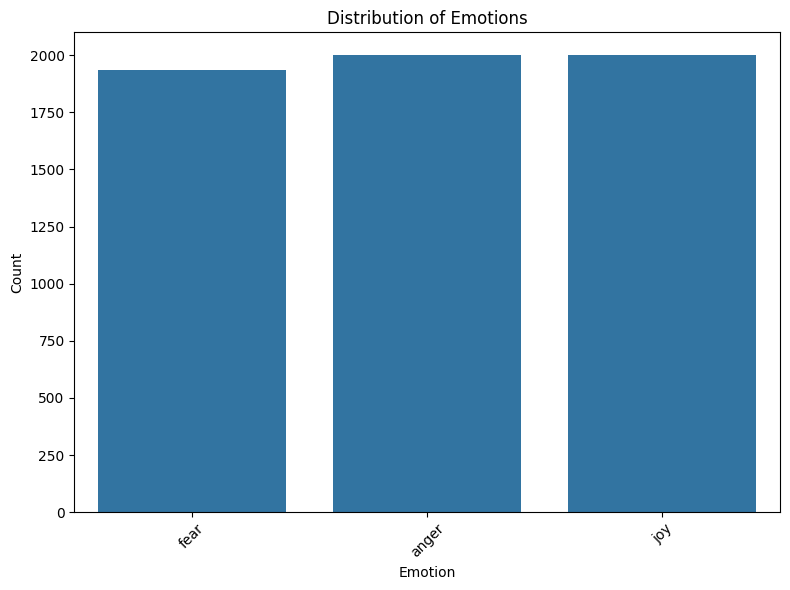

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Emotion')
plt.title('Distribution of Emotions')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('emotion_distribution.png')  # Save the plot
plt.show()

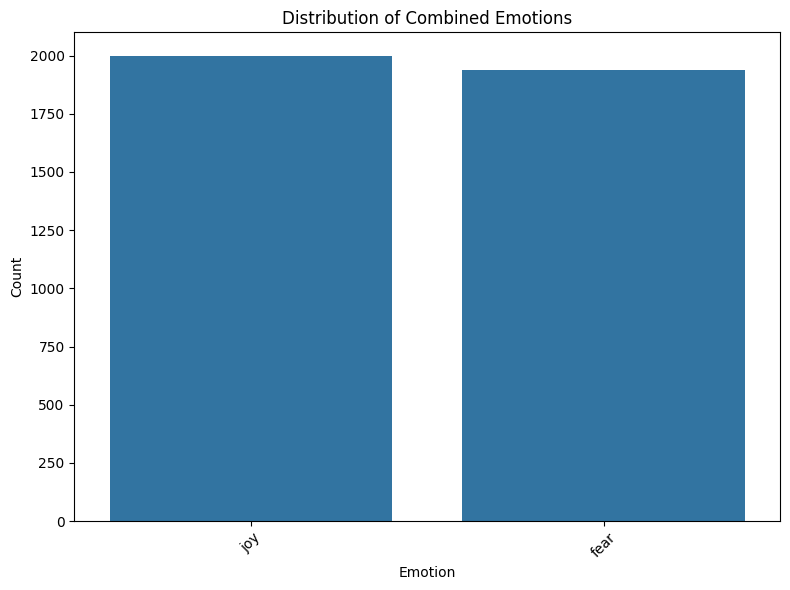

In [ ]:
df_joy = df[df['Emotion'] == 'joy'].head(3000)
df_fear = df[df['Emotion'] == 'fear'].head(3000)

# Combine joy and fear data
df_combined = pd.concat([df_joy, df_fear])

# Display the combined data
plt.figure(figsize=(8, 6))
sns.countplot(data=df_combined, x='Emotion')
plt.title('Distribution of Combined Emotions')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('combined_emotion_distribution.png')  # Save the plot
plt.show()


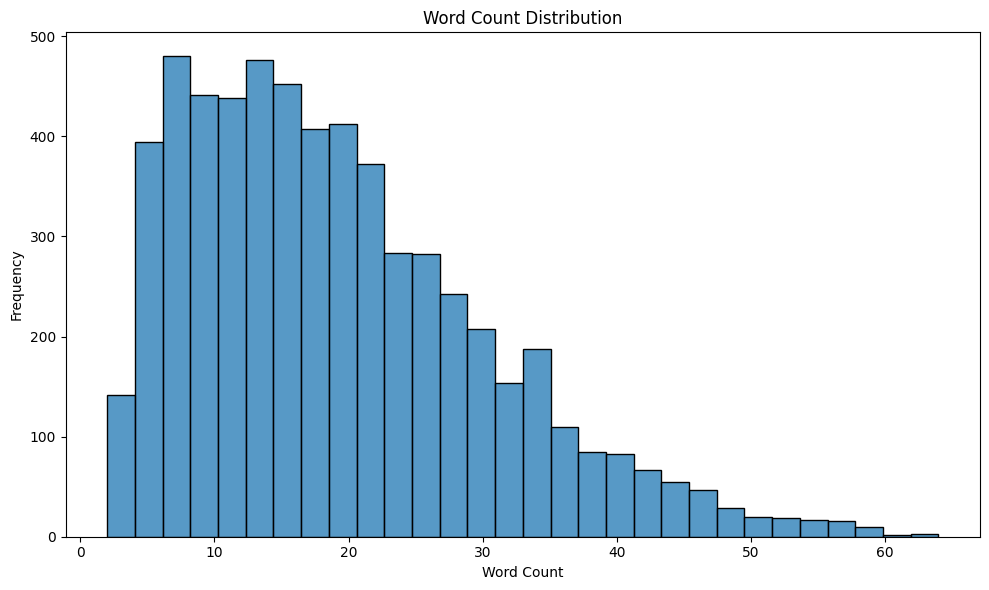

In [ ]:
df['word_count'] = df['Comment'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='word_count', bins=30)
plt.title('Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('Word_Count_distribution.png')  # Save the plot

plt.show()

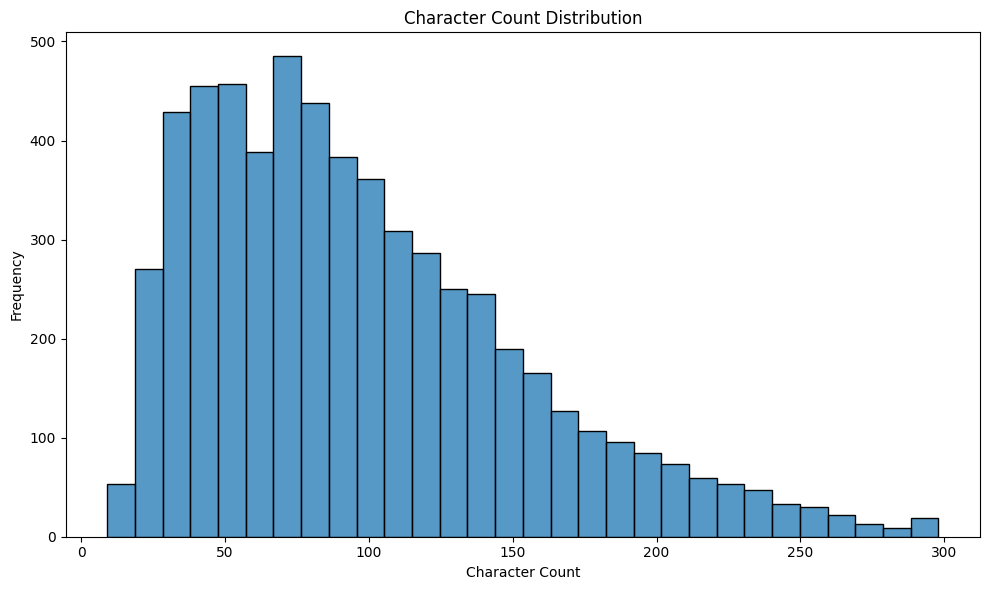

In [ ]:
df['char_count'] = df['Comment'].apply(lambda x: len(str(x)))
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='char_count', bins=30)
plt.title('Character Count Distribution')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('Character_Count_distribution.png')  # Save the plot

plt.show()

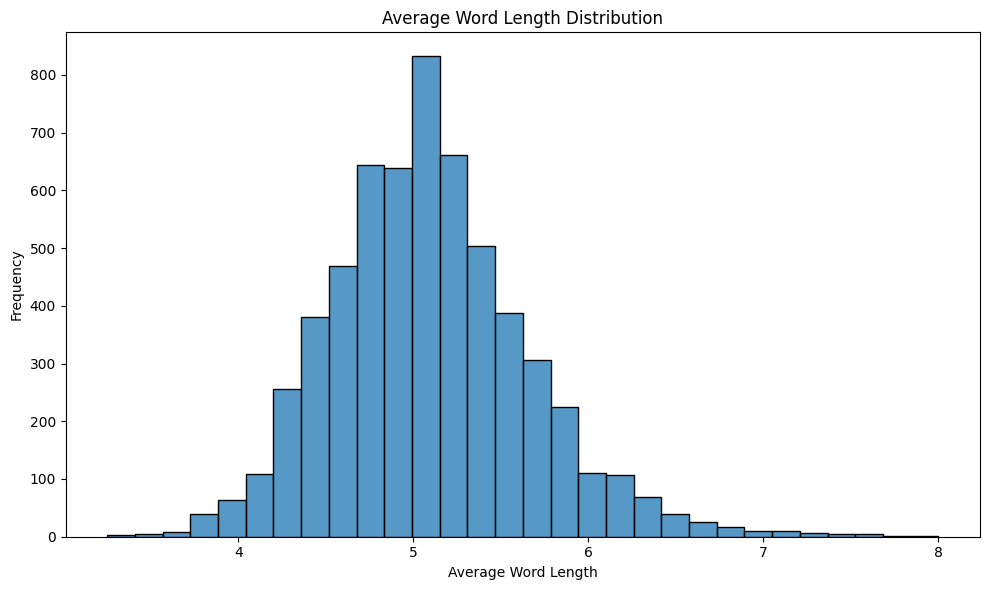

In [ ]:
df['avg_word_length'] = df['char_count'] / df['word_count']
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='avg_word_length', bins=30)
plt.title('Average Word Length Distribution')
plt.xlabel('Average Word Length')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('Average_Word_Length.png')  # Save the plot

plt.show()

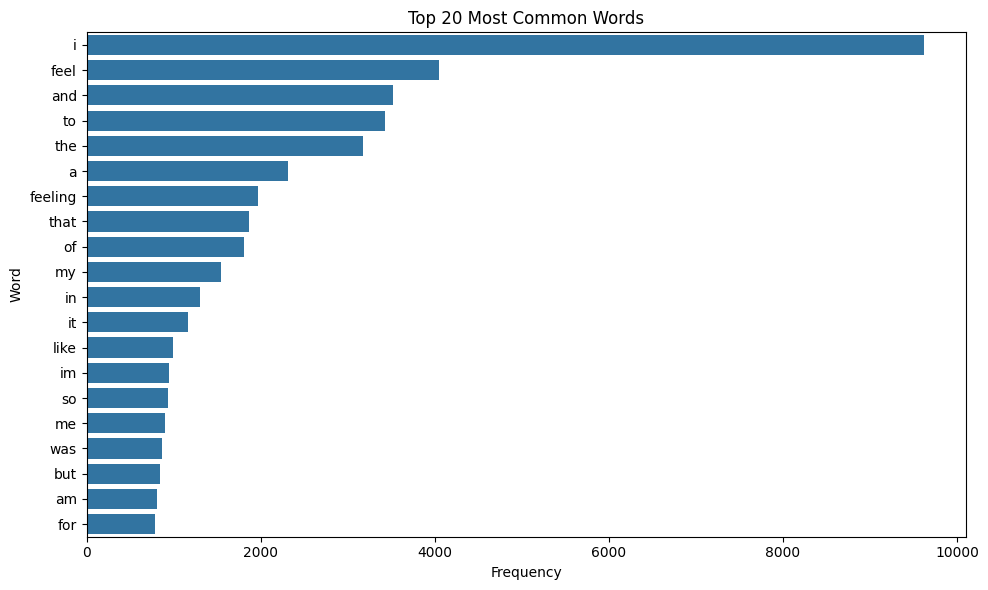

In [ ]:
from collections import Counter
from nltk.tokenize import word_tokenize

all_words = ' '.join(df['Comment']).split()
word_freq = Counter(all_words)
common_words = word_freq.most_common(20)
common_words_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

plt.figure(figsize=(10, 6))
sns.barplot(data=common_words_df, x='Frequency', y='Word')
plt.title('Top 20 Most Common Words')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.savefig('Top20_Common_words.png')  # Save the plot

plt.show()

Preprocessing and Tokenization


In [ ]:
df_joy = df[df['Emotion'] == 'joy']

In [ ]:
df_joy.shape

(2000, 5)

In [ ]:
df_joy = df_joy[['Emotion', 'Comment']]

In [ ]:
df_joy = df_joy.iloc[:3000]

In [ ]:
df_fear = df[df['Emotion'] == 'fear']

In [ ]:
df_fear = df_fear.iloc[:3000]

In [ ]:
df_joy.shape, df_fear.shape

((2000, 2), (1937, 5))

In [ ]:
df_fear.head()

,Comment,Emotion,word_count,char_count,avg_word_length
0,i seriously hate one subject to death but now ...,fear,15,73,4.866667
2,i sit here to write i start to dig out my feel...,fear,29,131,4.517241
4,i feel suspicious if there is no one outside l...,fear,16,87,5.437500
12,i was bitten by a dog,fear,6,21,3.500000
19,i feel like i have to redeem myself even thoug...,fear,23,110,4.782609


In [ ]:
df_fear = df_fear[['Emotion', 'Comment']]

In [ ]:
df_data = pd.concat([df_joy, df_fear])

In [ ]:
df_data['Emotion'].value_counts()

,count
Emotion,
joy,2000
fear,1937


In [ ]:
df_data['Emotion'] = df_data['Emotion'].replace({'joy': 1, 'fear': 0})

/tmp/ipykernel_190/3240239925.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_data['Emotion'] = df_data['Emotion'].replace({'joy': 1, 'fear': 0})


In [ ]:
df_data.head()

,Emotion,Comment
3,1,ive been really angry with r and i feel like a...
9,1,i feel like i ve regained another vital part o...
10,1,i feel a bit like franz liebkind in the produc...
11,1,i was feeling at the start didnt want to move ...
13,1,i do not always find myself feeling thankful b...


In [ ]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
import re
from nltk.tokenize import word_tokenize


In [ ]:
import re
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt_tab')

def remove_special_characters(text):
    # Tokenize the text into words
    words = word_tokenize(text)

    # Remove special characters
    clean_words = [re.sub(r'[^a-zA-Z0-9]', '', word) for word in words]

    # Join words back
    clean_text = ' '.join(clean_words)
    return clean_text

# Apply function
df_data['Comment'] = df_data['Comment'].apply(remove_special_characters)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
df_data['Comment'] = df_data['Comment'].str.lower()

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
!pip install gensim
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split


np.random.seed(42)
tf.random.set_seed(42)
X_train, X_test, y_train, y_test = train_test_split(df_data['Comment'], df_data['Emotion'], stratify = df_data['Emotion'], random_state=42)

In [ ]:
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
stop_words = set(stopwords.words('english'))
def preprocess(text):
    text = text.lower()
    text = ''.join([word for word in text if word not in string.punctuation])
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

X_train = X_train.apply(preprocess)
X_test = X_test.apply(preprocess)

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

vocab_size = len(tokenizer.word_index) + 1

# Pad the sequences to a fixed length
max_length = 100
X_train = pad_sequences(X_train, maxlen=max_length, padding='post')
X_test = pad_sequences(X_test, maxlen=max_length, padding='post')

In [ ]:
sentences = tokenizer.sequences_to_texts(X_train)  # Convert sequences back to texts
sentences = [sentence.split() for sentence in sentences]

w2v_model = Word2Vec(sentences, vector_size=200, window=10, min_count=3, workers=1)


# Create a weight matrix for the embedding layer
embedding_matrix = np.zeros((vocab_size,200))
for word, i in tokenizer.word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]


 **Convolutional Neural Network (CNN)**

1. **Embedding Layer**:
   - Converts input sequences into dense vectors of fixed size.
   - Parameters: `vocab_size` (vocabulary size), `200` (embedding dimensions), `embedding_matrix` (pre-trained embeddings), `max_length` (input length), `trainable=True` (allowing the embedding to be updated during training).

2. **First Convolutional Layer**:
   - `Conv1D(128, 5, activation='relu')`: Applies 128 filters of size 5 with ReLU activation.

3. **First Pooling Layer**:
   - `MaxPooling1D(5)`: Reduces the dimensionality by taking the maximum value over a window of size 5.

4. **Second Convolutional Layer**:
   - `Conv1D(128, 5, activation='relu')`: Applies another set of 128 filters of size 5 with ReLU activation.

5. **Second Pooling Layer**:
   - `MaxPooling1D(5)`: Further reduces dimensionality with another window of size 5.

6. **Flatten Layer**:
   - Converts the 2D matrix to a 1D vector.

7. **Dense Layers**:
   - `Dense(256, activation='relu')`: Fully connected layer with 256 neurons and ReLU activation.
   - `Dense(128, activation='relu')`: Fully connected layer with 128 neurons and ReLU activation.

8. **Output Layer**:
   - `Dense(1, activation='sigmoid')`: Output layer with a single neuron and sigmoid activation for binary classification.

9. **Compilation**:
   - `model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])`: Compiles the model with the Adam optimizer, binary cross-entropy loss, and accuracy metric.

In [ ]:
model = Sequential()
model.add(Embedding(vocab_size, 200, weights=[embedding_matrix], input_length=max_length, trainable=True))
model.add(Conv1D(128, 5, activation='relu'))
model.add(MaxPooling1D(5))
model.add(Conv1D(128, 5, activation='relu'))
model.add(MaxPooling1D(5))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - accuracy: 0.5078 - loss: 0.6954 - val_accuracy: 0.6629 - val_loss: 0.5992
Epoch 2/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.7912 - loss: 0.4335 - val_accuracy: 0.9107 - val_loss: 0.2331
Epoch 3/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.9856 - loss: 0.0434 - val_accuracy: 0.9340 - val_loss: 0.1686
Epoch 4/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - accuracy: 0.9982 - loss: 0.0093 - val_accuracy: 0.9371 - val_loss: 0.2083
Epoch 5/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - accuracy: 0.9996 - loss: 0.0052 - val_accuracy: 0.9584 - val_loss: 0.1472
Epoch 6/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.9999 - loss: 4.1088e-04 - val_accuracy: 0.9624 - val_loss: 0.1239
Epoch 7/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step - accuracy: 1.0000 - loss: 1.1336e-04 - val_accuracy: 0.9574 - val_loss: 0.1466
Epoch 8/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 1.0000 - loss: 8.2206e-05 - val_accu

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f'Accuracy on test data: {accuracy * 100:.2f}%')

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9681 - loss: 0.1527
Accuracy on test data: 96.14%


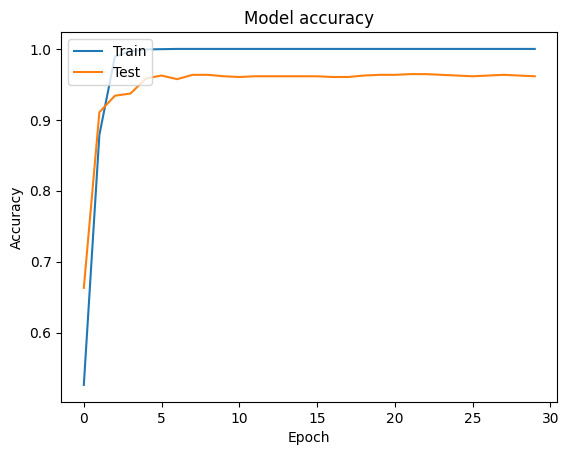

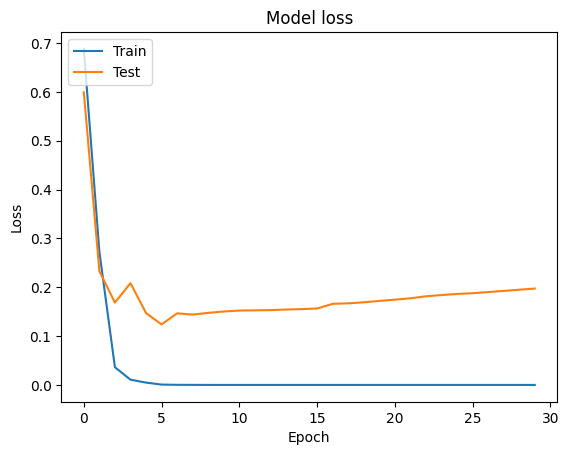

In [ ]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.savefig('cnn_model_accuracy_plot.png')  # Save before showing
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.savefig('cnn_model_loss_plot.png')  # Save before showing
plt.show()


**Artificial Neural Network (ANN)**

1. **Embedding Layer**:
   - Converts input sequences into dense vectors of fixed size.
   - Parameters: `vocab_size` (vocabulary size), `200` (embedding dimensions), `embedding_matrix` (pre-trained embeddings), `max_length` (input length), `trainable=True` (allowing the embedding to be updated during training).

2. **Flatten Layer**:
   - Converts the 2D matrix from the embedding layer to a 1D vector.

3. **Dense Layers**:
   - `Dense(256, activation='relu')`: Fully connected layer with 256 neurons and ReLU activation.
   - `Dense(128, activation='relu')`: Fully connected layer with 128 neurons and ReLU activation.
   - `Dense(64, activation='relu')`: Fully connected layer with 64 neurons and ReLU activation.

4. **Output Layer**:
   - `Dense(1, activation='sigmoid')`: Output layer with a single neuron and sigmoid activation for binary classification.

5. **Compilation**:
   - `ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])`: Compiles the model with the Adam optimizer, binary cross-entropy loss, and accuracy metric.

In [ ]:
ann_model = Sequential()
ann_model.add(Embedding(vocab_size, 200, weights=[embedding_matrix], input_length=max_length, trainable=True))
ann_model.add(Flatten())
ann_model.add(Dense(256, activation='relu'))
ann_model.add(Dense(128, activation='relu'))
ann_model.add(Dense(64, activation='relu'))
ann_model.add(Dense(1, activation='sigmoid'))

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
ann_history = ann_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 13s 118ms/step - accuracy: 0.5309 - loss: 0.7037 - val_accuracy: 0.5665 - val_loss: 0.6798
Epoch 2/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.6244 - loss: 0.6079 - val_accuracy: 0.9117 - val_loss: 0.1951
Epoch 3/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 16s 171ms/step - accuracy: 0.9700 - loss: 0.0835 - val_accuracy: 0.9391 - val_loss: 0.1514
Epoch 4/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.9921 - loss: 0.0188 - val_accuracy: 0.9411 - val_loss: 0.1492
Epoch 5/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 102ms/step - accuracy: 0.9982 - loss: 0.0067 - val_accuracy: 0.9228 - val_loss: 0.2912
Epoch 6/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.9979 - loss: 0.0084 - val_accuracy: 0.9452 - val_loss: 0.1838
Epoch 7/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.9980 - loss: 0.0038 - val_accuracy: 0.9391 - val_loss: 0.2004
Epoch 8/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.9991 - loss: 0.0023 - val_accura

In [ ]:
loss, accuracy = ann_model.evaluate(X_test, y_test)

print(f'Accuracy on test data: {accuracy * 100:.2f}%')

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9314 - loss: 0.3023
Accuracy on test data: 94.01%


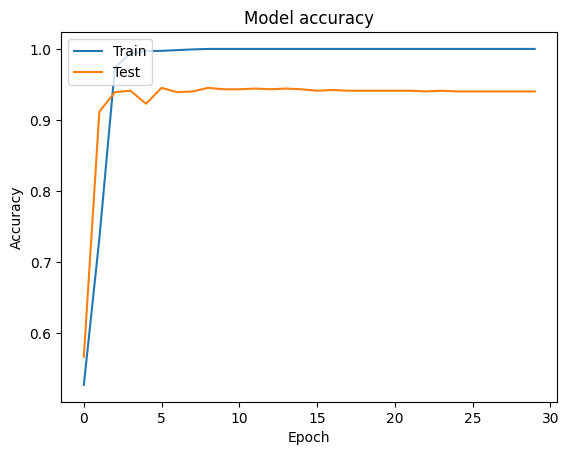

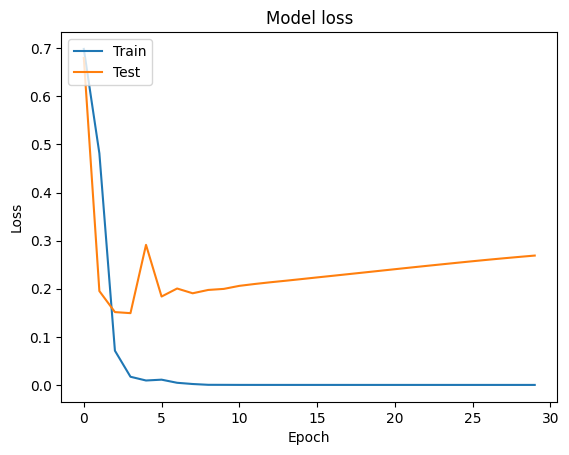

In [ ]:
# Plot training & validation accuracy values
plt.plot(ann_history.history['accuracy'])
plt.plot(ann_history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.savefig('ann_model_accuracy_plot.png')  # Save before showing
plt.show()

# Plot training & validation loss values
plt.plot(ann_history.history['loss'])
plt.plot(ann_history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.savefig('ann_model_loss_plot.png')  # Save before showing
plt.show()


RNN MODEL


In [ ]:
df['Emotion'].value_counts()

,count
Emotion,
anger,2000
joy,2000
fear,1937


In [ ]:
df['Object'] = df['Emotion'].astype("category").cat.codes

In [ ]:
df.head()


,Comment,Emotion,word_count,char_count,avg_word_length,Object
0,i seriously hate one subject to death but now ...,fear,15,73,4.866667,1
1,im so full of life i feel appalled,anger,8,34,4.250000,0
2,i sit here to write i start to dig out my feel...,fear,29,131,4.517241,1
3,ive been really angry with r and i feel like a...,joy,19,89,4.684211,2
4,i feel suspicious if there is no one outside l...,fear,16,87,5.437500,1


In [ ]:
total_categories = len(df['Object'].unique())
total_categories

3

In [ ]:
from sklearn.model_selection import train_test_split

random_seed = 42

df_train, df_test = train_test_split(df, test_size=0.3, random_state=random_seed)


In [ ]:
df_train.head()

,Comment,Emotion,word_count,char_count,avg_word_length,Object
2881,i also chat when i feel frustrated with guys b...,anger,17,84,4.941176,0
402,i am if i go back to the hostel for a break i ...,fear,28,111,3.964286,1
4593,i got caught shoplifting a package of gummy bears,fear,9,49,5.444444,1
5057,i do not believe all media content is bad in f...,joy,22,107,4.863636,2
949,i feel like the sequel was ok but overrated no...,joy,19,81,4.263158,2


In [ ]:
MAX_VOCAB_SIZE = 2000
tokenizer = Tokenizer(num_words = MAX_VOCAB_SIZE) # only tikenize the top 3000 words most frequents
tokenizer.fit_on_texts(df_train['Comment'])
sequences_train = tokenizer.texts_to_sequences(df_train['Comment'])
sequences_test = tokenizer.texts_to_sequences(df_test['Comment'])

In [ ]:
# Total words found in the dictionary
word2idx = tokenizer.word_index
total_words = len(word2idx)
print(f'total unique words {total_words}')

total unique words 7273


In [ ]:
# pad sequences
data_train = pad_sequences(sequences_train)
print(f'Shape of data train tensor: {data_train.shape}')

# get sequence length
length = data_train.shape[1]

Shape of data train tensor: (4155, 60)


In [ ]:
data_test = pad_sequences(sequences_test, maxlen=length)
print('Shape of data test tensor:', data_test.shape)

Shape of data test tensor: (1782, 60)


**Recurrent Neural Network(RNN)**

1. **Input Layer**:
   - `Input(shape=(length,))`: Specifies the input shape of the sequences.

2. **Embedding Layer**:
   - `Embedding(total_words+1, D)`: Converts input sequences into dense vectors of size \(D = 50\).

3. **LSTM Layer**:
   - `LSTM(32, return_sequences=True)`: Applies an LSTM with 32 units, returning the full sequence.

4. **Global Max Pooling Layer**:
   - `GlobalMaxPool1D()`: Reduces the sequence by taking the maximum value over each feature.

5. **Dense Layer**:
   - `Dense(total_categories)`: Fully connected layer with a number of neurons equal to the total categories.

6. **Model Definition**:
   - `model = Model(i, x)`: Creates the model with the specified input and output layers.

In [ ]:
D = 50

i = Input(shape=(length ,))
x = Embedding(total_words+1,D)(i)
x = LSTM(32, return_sequences=True)(x)
x = GlobalMaxPool1D()(x)
x = Dense(total_categories)(x)

model = Model(i,x)

In [ ]:
model.compile(
  loss=SparseCategoricalCrossentropy(from_logits=True),
  optimizer='adam',
  metrics=['accuracy']
)


In [ ]:
rnn = model.fit(
  data_train,
  df_train['Object'],
  epochs=30,
  validation_data=(data_test, df_test['Object'])
)

Epoch 1/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.4096 - loss: 1.0911 - val_accuracy: 0.7699 - val_loss: 0.8307
Epoch 2/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.8064 - loss: 0.6417 - val_accuracy: 0.9125 - val_loss: 0.2928
Epoch 3/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9506 - loss: 0.1996 - val_accuracy: 0.9141 - val_loss: 0.2363
Epoch 4/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9713 - loss: 0.1203 - val_accuracy: 0.9287 - val_loss: 0.2048
Epoch 5/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.9768 - loss: 0.0875 - val_accuracy: 0.9299 - val_loss: 0.2077
Epoch 6/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9862 - loss: 0.0632 - val_accuracy: 0.9321 - val_loss: 0.2130
Epoch 7/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9893 - loss: 0.0422 - val_accuracy: 0.9293 - val_loss: 0.2224
Epoch 8/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9927 - loss: 0.0335 - val_accu

In [ ]:
from sklearn.metrics import classification_report


predictions = model.predict(data_test)
y_pred = np.argmax(predictions, axis=1)


y_true = df_test['Object']


report = classification_report(y_true, y_pred)
print(report)

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
              precision    recall  f1-score   support

           0       0.91      0.92      0.91       600
           1       0.92      0.92      0.92       614
           2       0.93      0.93      0.93       568

    accuracy                           0.92      1782
   macro avg       0.92      0.92      0.92      1782
weighted avg       0.92      0.92      0.92      1782



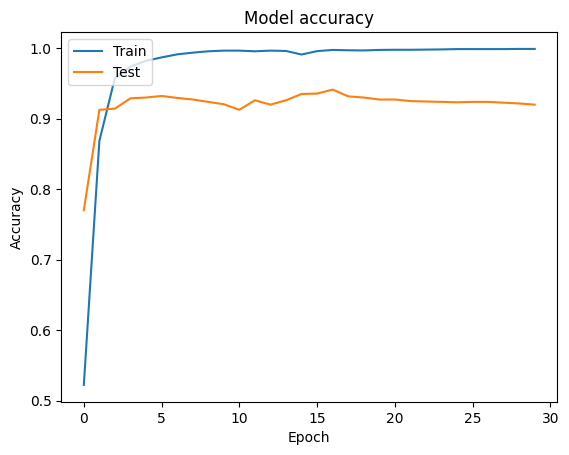

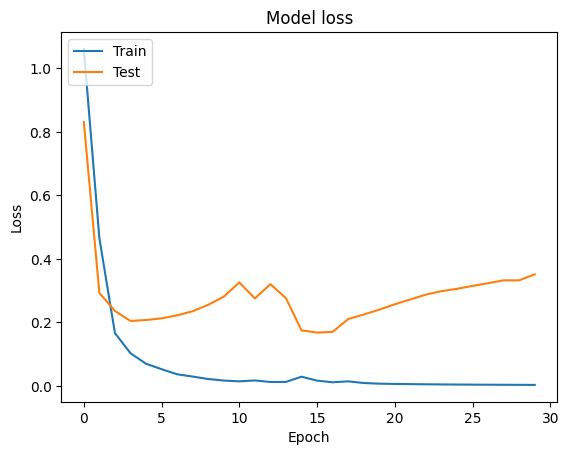

In [ ]:
# Plot training & validation accuracy values
plt.plot(rnn.history['accuracy'])
plt.plot(rnn.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.savefig('rnn_model_accuracy_plot.png')  # Save before showing
plt.show()

# Plot training & validation loss values
plt.plot(rnn.history['loss'])
plt.plot(rnn.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.savefig('rnn_model_loss_plot.png')  # Save before showing
plt.show()


COMPARISON


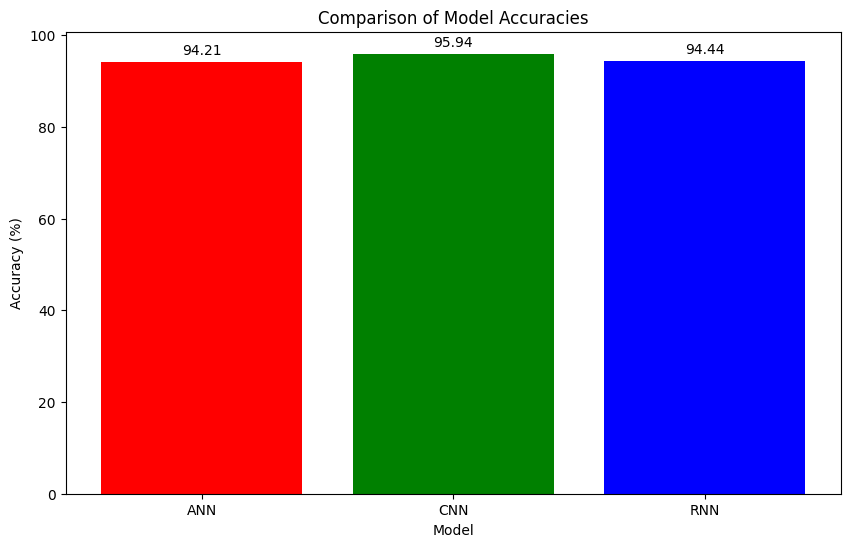

In [ ]:
import matplotlib.pyplot as plt

# Data for the bars
data = {'Model': ['ANN', 'CNN', 'RNN'], 'Accuracy': [94.21, 95.94, 94.44]}

# Create the figure
fig = plt.figure(figsize=(10, 6))

# Create the bars
bars = plt.bar(data['Model'], data['Accuracy'], color=['red', 'green', 'blue'])

# Add labels and title
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.title('Comparison of Model Accuracies')

# Add data labels to the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 1,
             round(yval, 2), ha='center', va='bottom')

# Save the plot
plt.savefig('model_comparison.png')

# Show the plot
plt.show()
